# tg pileup zero order

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
The CIAO setup for this window has changed from
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3
To:
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 1927
download_chandra_obsid 1927 evt1
mv -fv 1927/secondary/*evt1.fits.gz ./
gunzip -f *.fits.gz


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt1     fits       51 Mb  ####################          < 1 s  87459.0 kb/s

`1927/secondary/acisf01927_000N003_evt1.fits.gz' -> `./acisf01927_000N003_evt1.fits.gz'


---
# what's the problem?

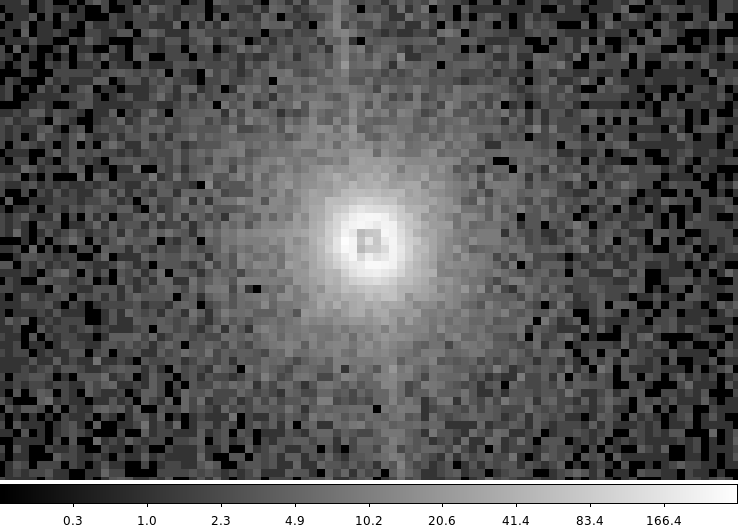

In [3]:
ds9 acisf01927_000N003_evt1.fits -scale log -zoom 8 \
  -pan to 4166 4119 physical \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

## tgdetect

In [4]:
pset tgdetect infile=acisf01927_000N003_evt1.fits
pset tgdetect outfile=tgd.fits
tgdetect mode=h clobber=yes


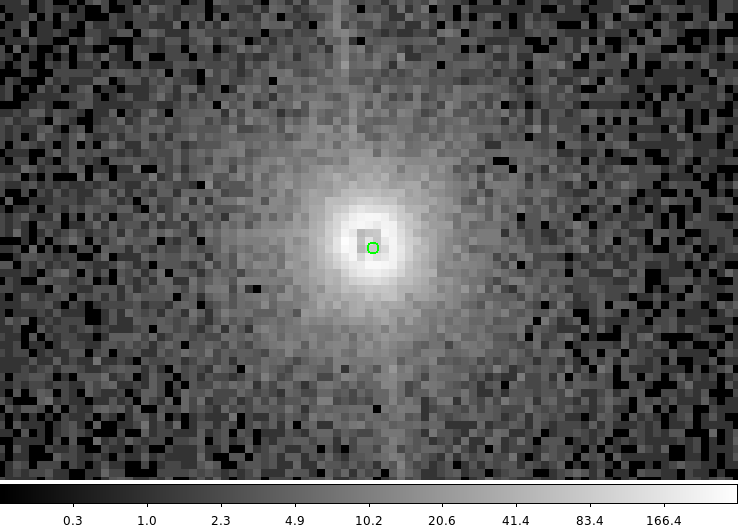

In [5]:
x=`dmkeypar tgd.fits x echo+`
y=`dmkeypar tgd.fits y echo+`
cat << EOM > point.reg
point(${x},${y}) # point=circle width=2
EOM

ds9 acisf01927_000N003_evt1.fits -scale log -zoom 8 \
  -pan to 4166 4119 physical \
  -regions point.reg \
  -saveimage png ds9_02.png -quit

display < ds9_02.png

## tg_findzo

In [6]:
pset tg_findzo infile=acisf01927_000N003_evt1.fits 
pset tg_findzo outfile=fzo.fits 
tg_findzo mode=h clob+


/export/ciao-4.9/binexe/tg_findzo:692: RuntimeWarning: invalid value encountered in greater
  & ( p.E_v < p.energy_filter_high ))
/export/ciao-4.9/binexe/tg_findzo:692: RuntimeWarning: invalid value encountered in less
  & ( p.E_v < p.energy_filter_high ))
/export/ciao-4.9/binexe/tg_findzo:752: RuntimeWarning: invalid value encountered in greater
  & ( p.E_v < p.energy_filter_high ))
/export/ciao-4.9/binexe/tg_findzo:752: RuntimeWarning: invalid value encountered in less
  & ( p.E_v < p.energy_filter_high ))
/export/ciao-4.9/binexe/tg_findzo:813: RuntimeWarning: invalid value encountered in greater
  & ( p.E_v < p.energy_m ) )   # 8000.
/export/ciao-4.9/binexe/tg_findzo:813: RuntimeWarning: invalid value encountered in less
  & ( p.E_v < p.energy_m ) )   # 8000.
/export/ciao-4.9/binexe/tg_findzo:891: RuntimeWarning: invalid value encountered in greater
  & ( p.E_v< p.energy_m ) )   # 8000.
/export/ciao-4.9/binexe/tg_findzo:891: RuntimeWarning: invalid value encountered in less
  & ( p.

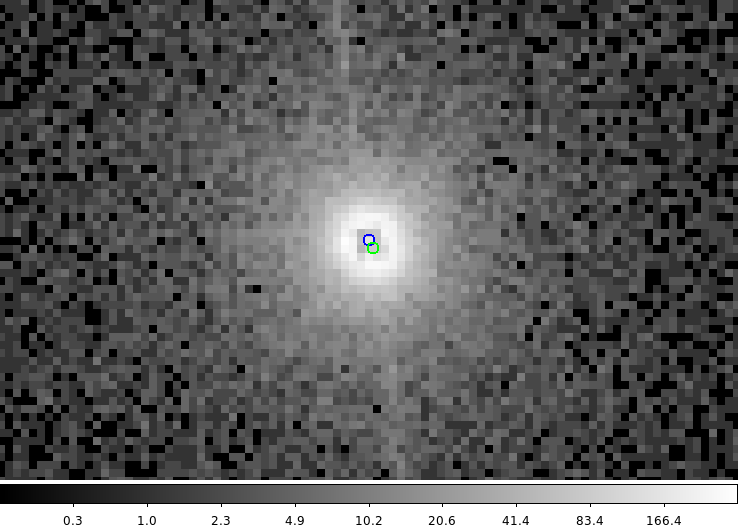

In [7]:
x=`dmkeypar fzo.fits x echo+`
y=`dmkeypar fzo.fits y echo+`
cat << EOM > point_fzo.reg
point(${x},${y}) # point=circle width=2 color=blue
EOM

ds9 acisf01927_000N003_evt1.fits -scale log -zoom 8 \
  -pan to 4166 4119 physical \
  -regions point.reg \
  -regions point_fzo.reg \
  -saveimage png ds9_03.png -quit

display < ds9_03.png

## tg_create_mask

In [8]:
pset tg_create_mask infile= acisf01927_000N003_evt1.fits
pset tg_create_mask outfile=tg_mask.fits
pset tg_create_mask input_pos_tab= fzo.fits
tg_create_mask mode=h clob+


In [9]:
dmlist tg_mask.fits"[cols shape,sky]" data

 
--------------------------------------------------------------------------------
Data for Table Block REGION
--------------------------------------------------------------------------------
 
ERROR: regCreateCircle() requires an input radius.ERROR: regCreateBox() requires two (2) radii.ERROR: regCreateBox() requires two (2) radii.Region Block: Empty region
ROW    SHAPE              SKY(X,Y)
 
     1 circle             (     4165.9833984375,     4118.9604492188)
     2 rotbox             (     4092.9177246094,     4102.0375976562)
     3 rotbox             (     4091.0917968750,     4114.9301757812)


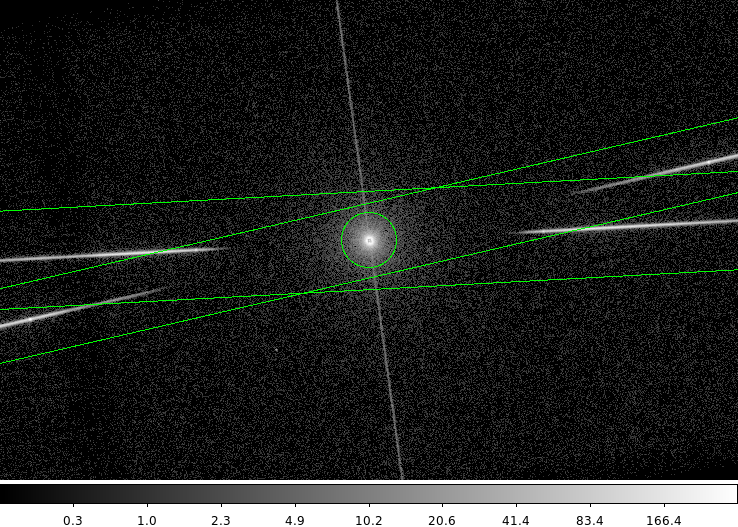

In [10]:
ds9 acisf01927_000N003_evt1.fits -region tg_mask.fits \
  -scale log \
    -pan to 4166 4119 physical \
  -saveimage png ds9_04.png -quit

display < ds9_04.png


# Cleanup


In [ ]:
/bin/rm -rf 1927 
/bin/rm -f acisf*
